# CIT / Fouling Analysis — เดินเรื่องเองตั้งแต่ต้น (ฉบับส่วนตัว)

**หมายเหตุสำคัญ:** notebook นี้เป็นการวิเคราะห์อิสระที่เขียนสูตร/logic ใหม่ทั้งหมดด้วยตัวเอง
เพื่อให้เข้าใจทุกขั้นตอนได้จริง **ไม่ได้ import ฟังก์ชันจาก `src/`** และ **ไม่ได้อ่านผลลัพธ์ที่คำนวณไว้แล้ว**
จาก pipeline การผลิต (`notebooks/production/`) — ทุกอย่างเริ่มจากไฟล์ Excel ดิบ

- **Inputs:** `Process information data (2024-2026).xlsx`, `Curde Property.xlsx` (จาก `CPHT_DATA_DIR`)
- **Outputs:** ไม่มีการเขียนทับไฟล์ใดๆ ใน `Data/` หรือ `dashboard/data/` — เป็น notebook สำหรับสำรวจ/เรียนรู้เท่านั้น
  (ถ้าต้องการเก็บกราฟ จะเซฟไว้ที่ `figures/my_analysis/` แยกต่างหาก)
- **ขอบเขต:** ไม่แทนที่ pipeline การผลิตเดิม เป็นแค่การวิเคราะห์คู่ขนานเพื่อความเข้าใจของตัวเอง

## โครงเรื่อง 6 ขั้นตอน
1. ภาพรวมข้อมูล (HX sensors + crude property)
2. Clean ช่วง TAM และจัดการข้อมูลผิดปกติ
3. ใส่สูตร Q / ΔT / U-proxy / Fouling rate + วิเคราะห์ cleaning event
4. จัดอันดับ HX (ความสัมพันธ์กับ CIT, ความเสี่ยง fouling)
5. Feature engineering สำหรับพยากรณ์ CIT
6. เปรียบเทียบโมเดล + สำรวจแนวคิด network ระหว่าง HX

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 140)
plt.rcParams['figure.figsize'] = (11, 4)

DATA_DIR = os.environ.get('CPHT_DATA_DIR', r'C:\Desktop\Bangchak Internship 2026\Data')
PROCESS_XLSX = os.path.join(DATA_DIR, 'Process information data (2024-2026).xlsx')
CRUDE_XLSX = os.path.join(DATA_DIR, 'Curde Property.xlsx')

FIG_DIR = os.path.join('figures', 'my_analysis')
os.makedirs(FIG_DIR, exist_ok=True)

### เกณฑ์การจำแนกค่า: MEASURED / CALCULATED / INFERRED / ASSUMED

โปรเจกต์นี้กำหนดไว้ว่าต้องแยกแยะ 4 ประเภทนี้เสมอ (ดู `CLAUDE.md`) — สรุปสั้นๆ สำหรับ notebook นี้:

| ประเภท | ตัวอย่างใน notebook นี้ |
|---|---|
| **MEASURED** | ค่าดิบจากเซนเซอร์ทุก tag ใน `proc_raw`/`crude_raw` (flow, temperature, API, SG, ...) |
| **CALCULATED** | Q, ΔT, U-proxy (`Q_norm`) — คำนวณตรงไปตรงมาจากค่า MEASURED ด้วยสูตรฟิสิกส์ที่ระบุไว้ |
| **INFERRED** | Fouling rate (Section 3), ผลลัพธ์ cleaning-event gain (Section 3) — มาจากการตีความรูปแบบข้อมูล ไม่ใช่วัดตรงๆ และมีความไม่แน่นอนสูงกว่า |
| **ASSUMED** | ค่าคงที่ในสูตร Cp/ρ ของ crude (Watson–Nelson correlation coefficients) — เป็นสูตรมาตรฐานที่ยังไม่ได้ยืนยันกับข้อมูล lab ของโรงกลั่นนี้โดยตรง |

**E101G ไม่มีเซนเซอร์และไม่ได้ถูกอนุมานใน notebook นี้เลย** (ตัดออกจาก `HX_TAGS` ทั้งหมด — ดู Section 1)

## Section 1 — ภาพรวมข้อมูล (Data Collection Overview)

โหลดข้อมูลดิบตรงจากไฟล์ Excel สองไฟล์:
- **Process data**: ค่าจากเซนเซอร์รายวัน (DCS historian) ของ HX ทุกตัว
- **Crude property**: คุณสมบัติน้ำมันดิบที่เข้าโรงกลั่น (API, SG, viscosity, MCRT, asphaltenes)

ไฟล์ Process data มี metadata อยู่บนสุด (แถว tag/unit/description) ก่อนจะถึงข้อมูลจริง
จึงต้อง `skiprows=6` เพื่อข้ามไปยังแถวที่เป็น header จริง (`Timestamp`, `{tag} - Average`, ...)

In [2]:
proc_raw = pd.read_excel(PROCESS_XLSX, skiprows=6)
proc_raw = proc_raw.drop(columns=[c for c in proc_raw.columns if str(c).startswith('Unnamed')])
proc_raw = proc_raw.rename(columns={c: c.replace(' - Average', '') for c in proc_raw.columns})
proc_raw['Timestamp'] = pd.to_datetime(proc_raw['Timestamp'])
proc_raw = proc_raw.set_index('Timestamp').sort_index()

print('process data:', proc_raw.shape, '|', proc_raw.index.min().date(), '->', proc_raw.index.max().date())
proc_raw.describe().T.head(10)

process data: (2008, 98) | 2021-01-01 -> 2026-07-01


,count,mean,std,min,25%,50%,75%,max
00FIC001.pv,2008.0,78.914885,24.761352,0.000000,62.871497,82.148995,95.875854,147.367449
00FC501.pv,2008.0,29.191603,14.806785,0.000000,19.432817,31.427482,41.927640,51.425453
1AI001.pv,2008.0,1.855058,0.801442,0.000000,1.505668,1.620298,1.899740,9.560200
1FC020.pv,2008.0,122.870597,15.054723,0.000000,121.580239,126.007117,130.203834,157.500000
1FC021.pv,2008.0,122.804384,17.589641,0.000000,121.985365,126.313608,130.311453,157.500000
1FC022.pv,2008.0,123.438424,15.699122,0.764952,122.057459,126.988803,130.668481,157.500000
1FC023.pv,2008.0,122.297236,16.263705,0.000000,121.657522,126.195557,130.153707,157.500000
1FC035.pv,2008.0,130.064072,30.307076,0.000000,119.999510,140.000383,150.735707,162.915982
1FC062.pv,2008.0,0.581496,4.965822,0.000000,0.000000,0.000000,0.000000,75.944882
1FI007.pv,2008.0,183.164140,26.980353,0.914488,168.213261,191.782871,202.063860,223.874720


In [3]:
# Curde Property.xlsx: header อยู่แถวที่ 3 (index 2), ข้อมูลจริงเริ่มถัดไป
# มีบาง row เป็น placeholder ว่าง (sheet เตรียมไว้ล่วงหน้าถึงปี 2026) ต้อง dropna ทิ้ง
crude_raw = pd.read_excel(CRUDE_XLSX, header=2)
crude_raw = crude_raw.drop(columns=[c for c in crude_raw.columns if str(c).startswith('Unnamed')])
crude_raw = crude_raw.rename(columns={'Curde Feed': 'Date'})
crude_raw['Date'] = pd.to_datetime(crude_raw['Date'], errors='coerce')
crude_raw = crude_raw.dropna(subset=['Date', 'API (none)']).set_index('Date').sort_index()
crude_raw = crude_raw[~crude_raw.index.duplicated(keep='last')]

print('crude property:', crude_raw.shape, '|', crude_raw.index.min().date(), '->', crude_raw.index.max().date())
crude_raw.describe().T

crude property: (1876, 6) | 2021-04-01 -> 2026-06-25


,count,unique,top,freq
API (none),1876.0,289.0,39.300,48.0
Specific gravity at 15.6C (none),1869.0,455.0,0.831,23.0
Viscosity (kinematic) at 50.0C (cSt),1876.0,397.0,3.110,24.0
Viscosity (kinematic) at 100.0C (cSt),1876.0,293.0,1.560,47.0
Carbon Residue (MCRT) (% wgt),1876.0,483.0,1.020,42.0
Asphaltenes (C7) (% wgt),1876.0,505.0,0.119,20.0


### รายการ tag ของแต่ละ HX (ระบุเองจากความรู้หน้างาน — ข้อเท็จจริงของ plant ไม่ใช่ logic ที่ยืมมา)

จำเป็นต้องรู้ว่า tag ไหนคือ cold-in / cold-out / flow ของ HX แต่ละตัว ถึงจะคำนวณอะไรต่อได้เลย
รายการนี้พิมพ์เองจากข้อมูล P&ID/tag list ของโรงงาน (ไม่ได้ import จากไฟล์ config เดิม)

**E101G ไม่มีเซนเซอร์วัดอุณหภูมิของตัวเอง** จึงตัดออกจากการคำนวณโดยตรง (ต้องอนุมานถ้าจำเป็น ซึ่งไม่ทำใน notebook นี้)

In [4]:
HX_TAGS = {
    'E101AB':  {'flow': '1FI007.pv', 'cold_in': '1TI102.pv', 'cold_out': '1TI101.pv'},
    'E101CD':  {'flow': '1FI008.pv', 'cold_in': '1TI102.pv', 'cold_out': '1TI104.pv'},
    'E101EF':  {'flow': '1FI009.pv', 'cold_in': '1TI102.pv', 'cold_out': '1TI109.pv'},
    'E102':    {'flow': '1fi005.pv', 'cold_in': '1TI107.pv', 'cold_out': '1TI106.pv'},
    'E103AB':  {'flow': '1FI015.pv', 'cold_in': '1TI225.pv', 'cold_out': '1TI136.pv'},
    'E104':    {'flow': '1FI015.pv', 'cold_in': '1TI136.pv', 'cold_out': '1TI112.pv'},
    'E105AB':  {'flow': '1FI015.pv', 'cold_in': '1TI112.pv', 'cold_out': '1TI114.pv'},
    'E106AB':  {'flow': '1FI016.pv', 'cold_in': '1TI225.pv', 'cold_out': '1TI128.pv'},
    'E107AB':  {'flow': '1FI016.pv', 'cold_in': '1TI128.pv', 'cold_out': '1TI130.pv'},
    'E108AB':  {'flow': '1FI016.pv', 'cold_in': '1TI130.pv', 'cold_out': '1TI132.pv'},
    'E109AB':  {'flow': '1FI016.pv', 'cold_in': '1TI132.pv', 'cold_out': '1TI134.pv'},
    'E110ABC': {'flow': '1FI017.pv', 'cold_in': '1TI225.pv', 'cold_out': '1TI124.pv'},
    'E111':    {'flow': '1FI017.pv', 'cold_in': '1TI124.pv', 'cold_out': '1TI123.pv'},
    'E112AB':  {'flow': '1FI017.pv', 'cold_in': '1TI123.pv', 'cold_out': '1TI126.pv'},
    'E113A':   {'flow': '1fi005.pv', 'cold_in': '1TI115.pv', 'cold_out': '1TI116.pv'},
}
CIT_TAG = '1TI116.pv'          # = E113A cold_out พอดี (จุดสุดท้ายก่อนเข้าเตา)
TOTAL_CHARGE_TAG = '1fi005.pv'

all_tags_needed = {CIT_TAG, TOTAL_CHARGE_TAG}
for cfg in HX_TAGS.values():
    all_tags_needed.update(cfg.values())
missing = [t for t in all_tags_needed if t not in proc_raw.columns]
print('tag ที่หาไม่เจอในไฟล์:', missing)

tag ที่หาไม่เจอในไฟล์: []


C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2423411211.py:7: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2423411211.py:7: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2423411211.py:7: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2423411211.py:7: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2423411211.py:7: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2423411211.py:7: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) miss

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\l

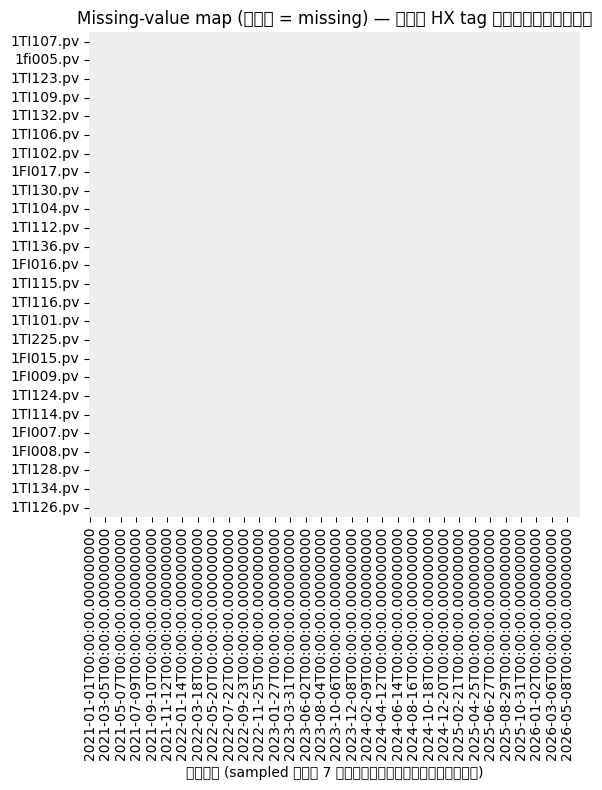

count    26.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
dtype: float64


In [5]:
miss_pct = proc_raw[list(all_tags_needed)].isna().mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(proc_raw[list(all_tags_needed)].isna().astype(int).iloc[::7].T, cbar=False,
            cmap=['#eeeeee', '#d1495b'], ax=ax)
ax.set_title('Missing-value map (แดง = missing) — ทุก HX tag ที่ใช้จริง')
ax.set_xlabel('เวลา (sampled ทุก 7 วันเพื่อให้ดูง่าย)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_missing_map.png'), dpi=110)
plt.show()
print(miss_pct.describe())

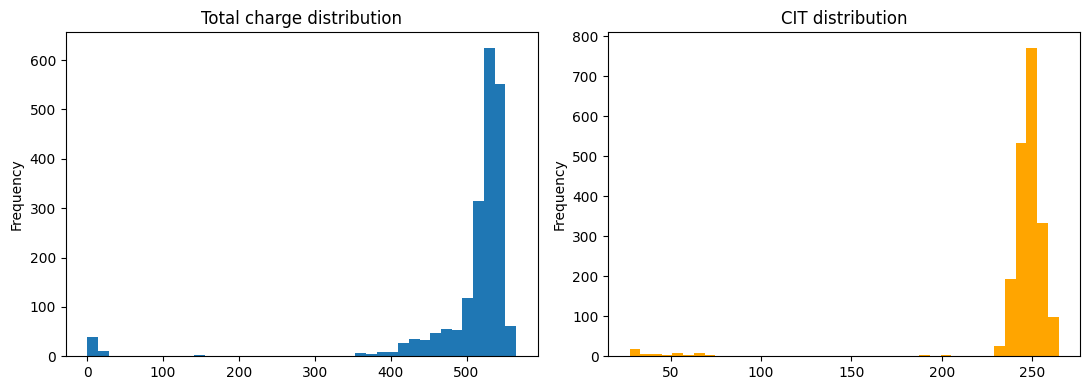

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
proc_raw[TOTAL_CHARGE_TAG].plot(kind='hist', bins=40, ax=axes[0], title='Total charge distribution')
proc_raw[CIT_TAG].plot(kind='hist', bins=40, ax=axes[1], title='CIT distribution', color='orange')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_hist_charge_cit.png'), dpi=110)
plt.show()

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:6: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:6: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:6: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:6: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:6: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:6: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing fro

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:7: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '01_raw_timeseries_overview.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:7: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '01_raw_timeseries_overview.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:7: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '01_raw_timeseries_overview.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:7: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '01_raw_timeseries_overview.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\363685852.py:7: 

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCa

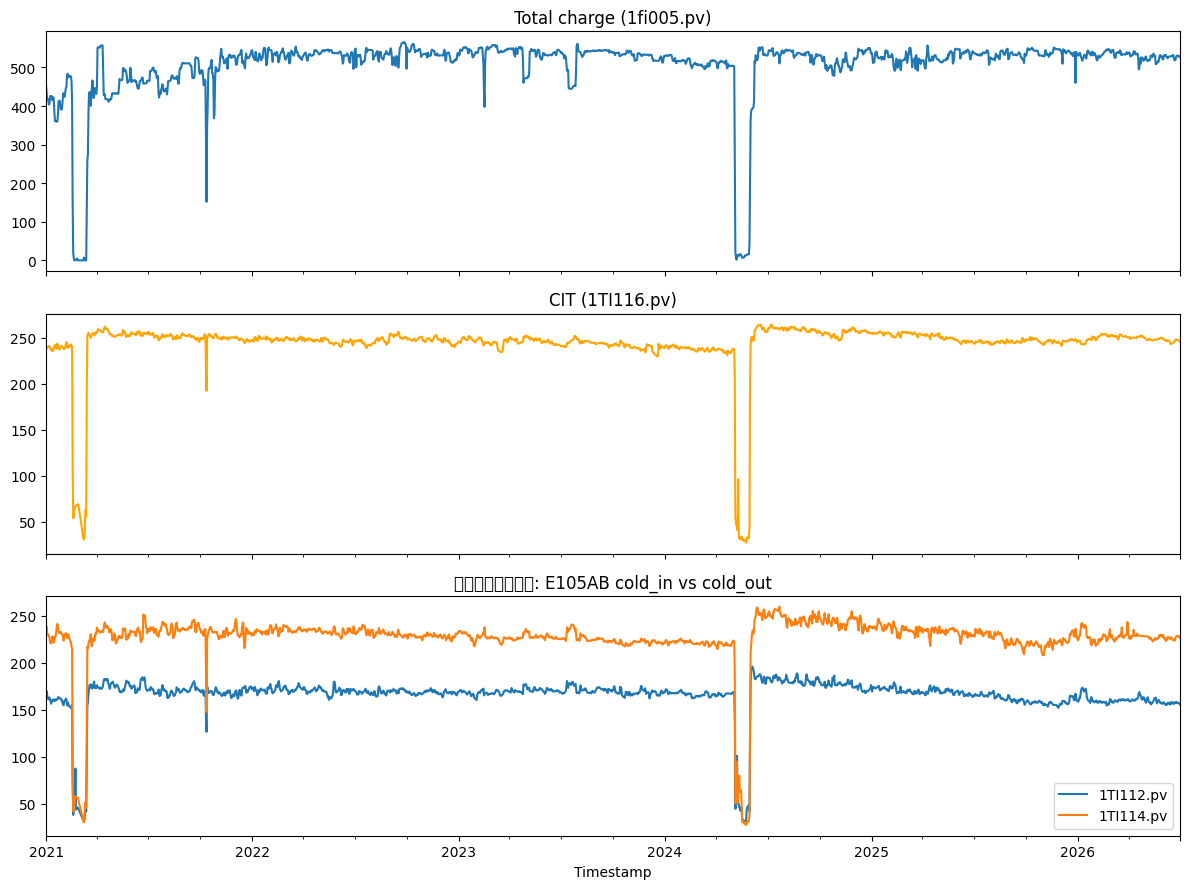

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
proc_raw[TOTAL_CHARGE_TAG].plot(ax=axes[0], title='Total charge (1fi005.pv)')
proc_raw[CIT_TAG].plot(ax=axes[1], color='orange', title='CIT (1TI116.pv)')
proc_raw[[HX_TAGS['E105AB']['cold_in'], HX_TAGS['E105AB']['cold_out']]].plot(ax=axes[2],
    title='ตัวอย่าง: E105AB cold_in vs cold_out')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_raw_timeseries_overview.png'), dpi=110)
plt.show()

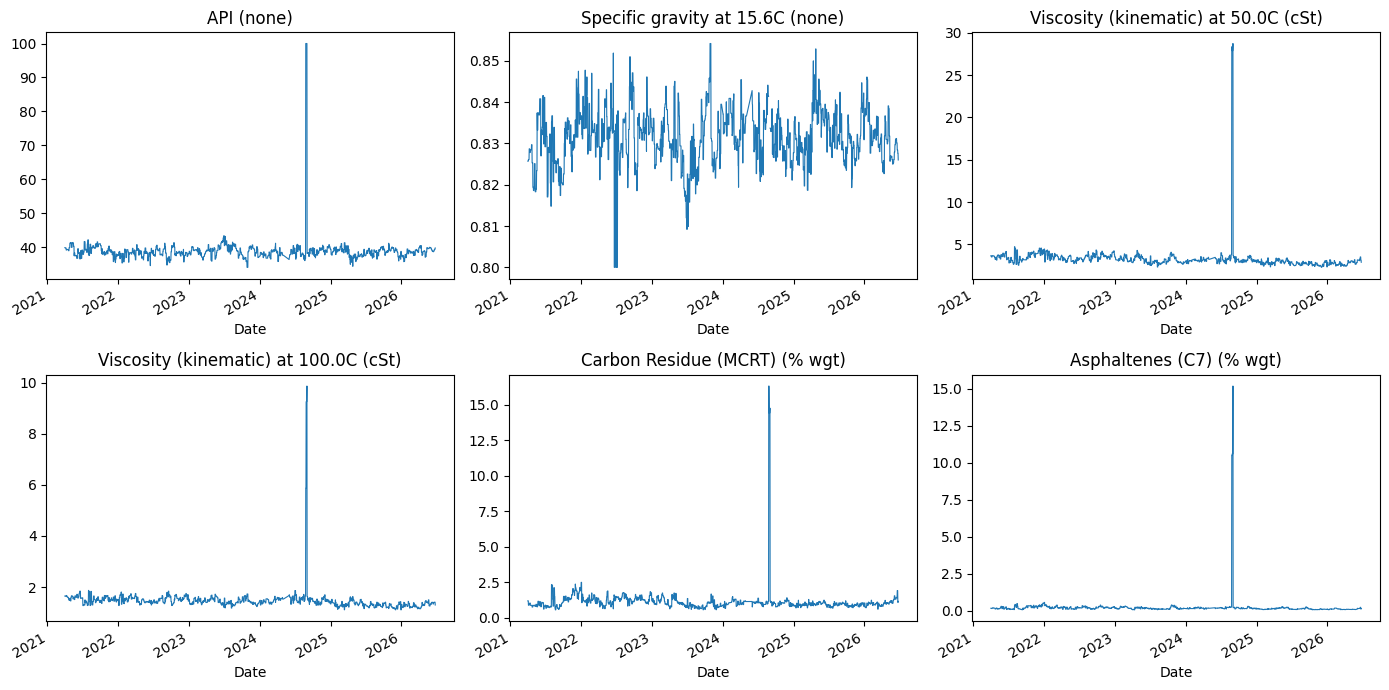

In [8]:
crude_cols = crude_raw.columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, crude_cols):
    crude_raw[col].plot(ax=ax, title=col, lw=0.8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_crude_property_trends.png'), dpi=110)
plt.show()

## Section 2 — Clean ช่วง TAM และข้อมูลผิดปกติ

**TAM (Turnaround Maintenance)** คือช่วงที่โรงงานหยุดเดินเครื่องทั้งระบบ — flow รวมจะตกลงมาต่ำมาก
ใช้ `total charge flow` (rolling median 30 วัน) เป็นตัวจับสัญญาณ แล้ว plot threshold ให้เห็นตรงๆ
(ไม่ hardcode ตัวเลขแบบไม่มีที่มา — ปรับ `SHUTDOWN_THRESH` ได้จากกราฟด้านล่าง)

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:15: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:15: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:15: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:15: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:15: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:15: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA 

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:16: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '02_tam_detection.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:16: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '02_tam_detection.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:16: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '02_tam_detection.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:16: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '02_tam_detection.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3531601485.py:16: UserWarning: Glyph 3607 (\N{THA

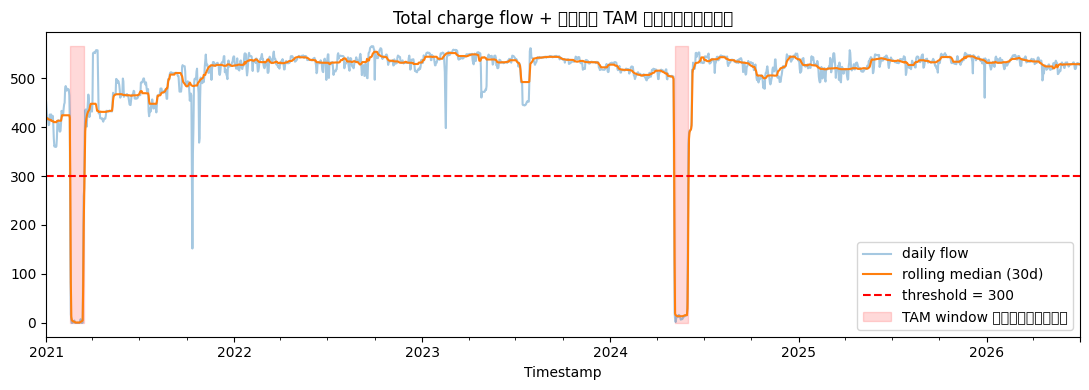

จำนวนวันที่ถูกจัดเป็น TAM: 56


In [9]:
SHUTDOWN_THRESH = 300  # m3/hr โดยประมาณ — ปรับดูจากกราฟด้านล่างได้ ถ้า flow ปกติอยู่แถว 1500+

flow = proc_raw[TOTAL_CHARGE_TAG]
flow_roll = flow.rolling(30, center=True, min_periods=5).median()
TAM_MASK = flow_roll < SHUTDOWN_THRESH

fig, ax = plt.subplots()
flow.plot(ax=ax, alpha=0.4, label='daily flow')
flow_roll.plot(ax=ax, label='rolling median (30d)')
ax.axhline(SHUTDOWN_THRESH, color='red', ls='--', label=f'threshold = {SHUTDOWN_THRESH}')
ax.fill_between(flow.index, 0, flow.max(), where=TAM_MASK.reindex(flow.index, fill_value=False),
                 color='red', alpha=0.15, label='TAM window ที่ตรวจพบ')
ax.legend()
ax.set_title('Total charge flow + ช่วง TAM ที่ตรวจพบ')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_tam_detection.png'), dpi=110)
plt.show()

print('จำนวนวันที่ถูกจัดเป็น TAM:', int(TAM_MASK.sum()))

### แก้ข้อมูลผิดปกติ (outlier) ของอุณหภูมิฝั่งเย็น (cold-side)

ใช้ 2 เกณฑ์ร่วมกัน: (1) rolling z-score (ค่าที่เบี่ยงจากค่าเฉลี่ยรอบข้างมากผิดปกติ)
(2) ขอบเขตทางฟิสิกส์ (อุณหภูมิ crude ในช่วงนี้ไม่ควรต่ำกว่า 30°C หรือสูงกว่า 380°C)
จุดที่ถูก flag จะแทนด้วยค่าเฉลี่ยเคลื่อนที่ (rolling mean) รอบๆ จุดนั้น

In [10]:
def correct_outliers(s, win=30, z_thresh=3.0, lo=30, hi=380):
    roll_mean = s.rolling(win, center=True, min_periods=5).mean()
    roll_std = s.rolling(win, center=True, min_periods=5).std()
    z = (s - roll_mean) / roll_std.replace(0, np.nan)
    bad = (z.abs() > z_thresh) | (s < lo) | (s > hi)
    bad = bad.fillna(False)
    fixed = s.copy()
    fixed[bad] = roll_mean[bad]
    return fixed, bad

temp_tags = sorted({cfg['cold_in'] for cfg in HX_TAGS.values()} | {cfg['cold_out'] for cfg in HX_TAGS.values()})
proc_clean = proc_raw.copy()
flag_counts = {}
for tag in temp_tags:
    fixed, bad = correct_outliers(proc_raw[tag])
    proc_clean[tag] = fixed
    flag_counts[tag] = int(bad.sum())

pd.Series(flag_counts).sort_values(ascending=False).head(10)

1TI225.pv    806
1TI130.pv     25
1TI128.pv     18
1TI126.pv     16
1TI132.pv     15
1TI134.pv     10
1TI123.pv     10
1TI114.pv     10
1TI115.pv      8
1TI102.pv      8
dtype: int64

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3747404540.py:7: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3747404540.py:7: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3747404540.py:7: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3747404540.py:7: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3747404540.py:7: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3747404540.py:7: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missi

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3747404540.py:8: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '02_outlier_correction_example.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3747404540.py:8: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '02_outlier_correction_example.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3747404540.py:8: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '02_outlier_correction_example.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3747404540.py:8: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '02_outlier_correction_example.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCa

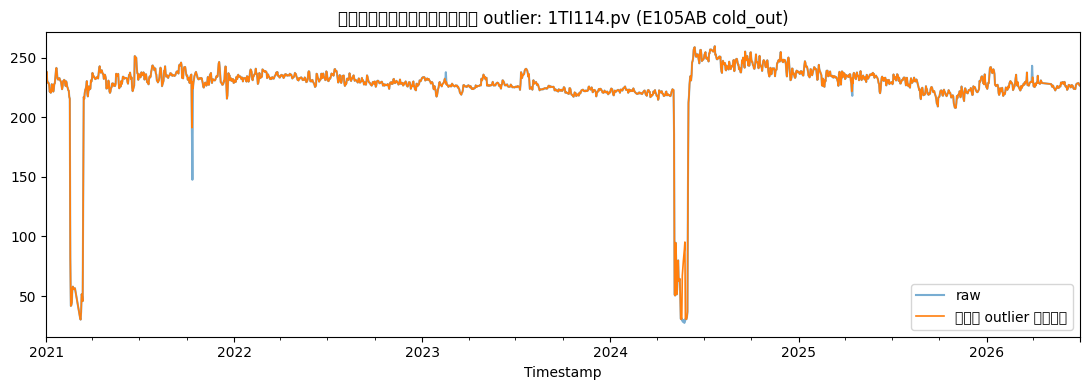

In [11]:
demo_tag = HX_TAGS['E105AB']['cold_out']
fig, ax = plt.subplots()
proc_raw[demo_tag].plot(ax=ax, label='raw', alpha=0.6)
proc_clean[demo_tag].plot(ax=ax, label='แก้ outlier แล้ว', lw=1.2)
ax.set_title(f'ตัวอย่างการแก้ outlier: {demo_tag} (E105AB cold_out)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_outlier_correction_example.png'), dpi=110)
plt.show()

## Section 3 — ใส่สูตร Q / ΔT / U-proxy / Fouling rate + วิเคราะห์ cleaning event

### สูตรที่ใช้ (เขียนเองในนี้ อ้างอิงหลักวิศวกรรมมาตรฐาน ไม่ import จาก src/)

- **Cp ของ crude** (Watson–Nelson correlation, หน่วย kJ/kg·K): ใช้อุณหภูมิเฉลี่ยและ SG
- **ρ (density) ของ crude**: ปรับจาก SG ที่ 15.6°C ด้วยสัมประสิทธิ์ขยายตัวทางความร้อนโดยประมาณ
- **Q (duty, kW)** = ρ × flow × Cp × ΔT_cold / 3600
- **Q_norm** = Q / total charge — ใช้เป็น proxy แทน U จริง เพราะไม่มีข้อมูลพื้นที่ผิว (Area) และ LMTD ในไฟล์ดิบชุดนี้
  (ถ้าต้องการ U จริงต้องยืนยันว่ามีข้อมูล Area ของแต่ละ HX ก่อน — ตอนนี้ใช้ Q_norm แทนไปก่อน)

In [12]:
def cp_crude_kJ_per_kgK(T_C, SG):
    T_F = T_C * 9 / 5 + 32
    cp_btu_per_lb_F = (0.388 + 0.00045 * T_F) / np.sqrt(SG)
    return cp_btu_per_lb_F * 4.1868

def rho_crude_kg_per_m3(T_C, SG):
    rho_15_6 = SG * 999.016
    alpha = 613.9723 / rho_15_6 ** 2
    return rho_15_6 * (1 - alpha * (T_C - 15.6))

sg_daily = crude_raw['Specific gravity at 15.6C (none)'].reindex(
    proc_clean.index.union(crude_raw.index)).sort_index().ffill().reindex(proc_clean.index)

cit = proc_clean[CIT_TAG].copy()
cit[TAM_MASK.reindex(cit.index, fill_value=False)] = np.nan

hx_results = {}
for hx, cfg in HX_TAGS.items():
    cold_in = proc_clean[cfg['cold_in']]
    cold_out = proc_clean[cfg['cold_out']]
    flow_hx = proc_clean[cfg['flow']]
    t_avg = (cold_in + cold_out) / 2
    cp = cp_crude_kJ_per_kgK(t_avg, sg_daily)
    rho = rho_crude_kg_per_m3(t_avg, sg_daily)
    dT = cold_out - cold_in
    Q_kW = rho * flow_hx * cp * dT / 3600
    Q_norm = Q_kW / proc_clean[TOTAL_CHARGE_TAG]
    df_hx = pd.DataFrame({'cold_in': cold_in, 'cold_out': cold_out, 'dT': dT,
                          'Q_kW': Q_kW, 'Q_norm': Q_norm})
    df_hx.loc[TAM_MASK.reindex(df_hx.index, fill_value=False), :] = np.nan
    hx_results[hx] = df_hx

hx_results['E105AB'].describe()

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\29499592.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  proc_clean.index.union(crude_raw.index)).sort_index().ffill().reindex(proc_clean.index)


,cold_in,cold_out,dT,Q_kW,Q_norm
count,1952.000000,1952.000000,1952.000000,1890.000000,1890.000000
mean,168.717594,230.534006,61.816412,6716.484801,12.840569
std,6.705716,8.179454,6.215481,1050.119021,1.775402
min,139.488441,185.652515,27.135258,2223.131022,5.756497
25%,165.306346,224.982978,57.096574,5931.775042,11.393926
50%,168.874108,229.572919,62.392335,6759.802069,12.894137
75%,172.090510,234.917831,66.485121,7553.431755,14.222411
max,195.867855,259.564665,80.217387,9165.346955,21.094594


C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:13: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:13: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:13: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:13: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:13: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:13: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) mis

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3591 (\N{THAI CH

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3591 (\N{THAI CH

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4226200749.py:14: UserWarning: Glyph 3591 (\N{THAI CH

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\lo

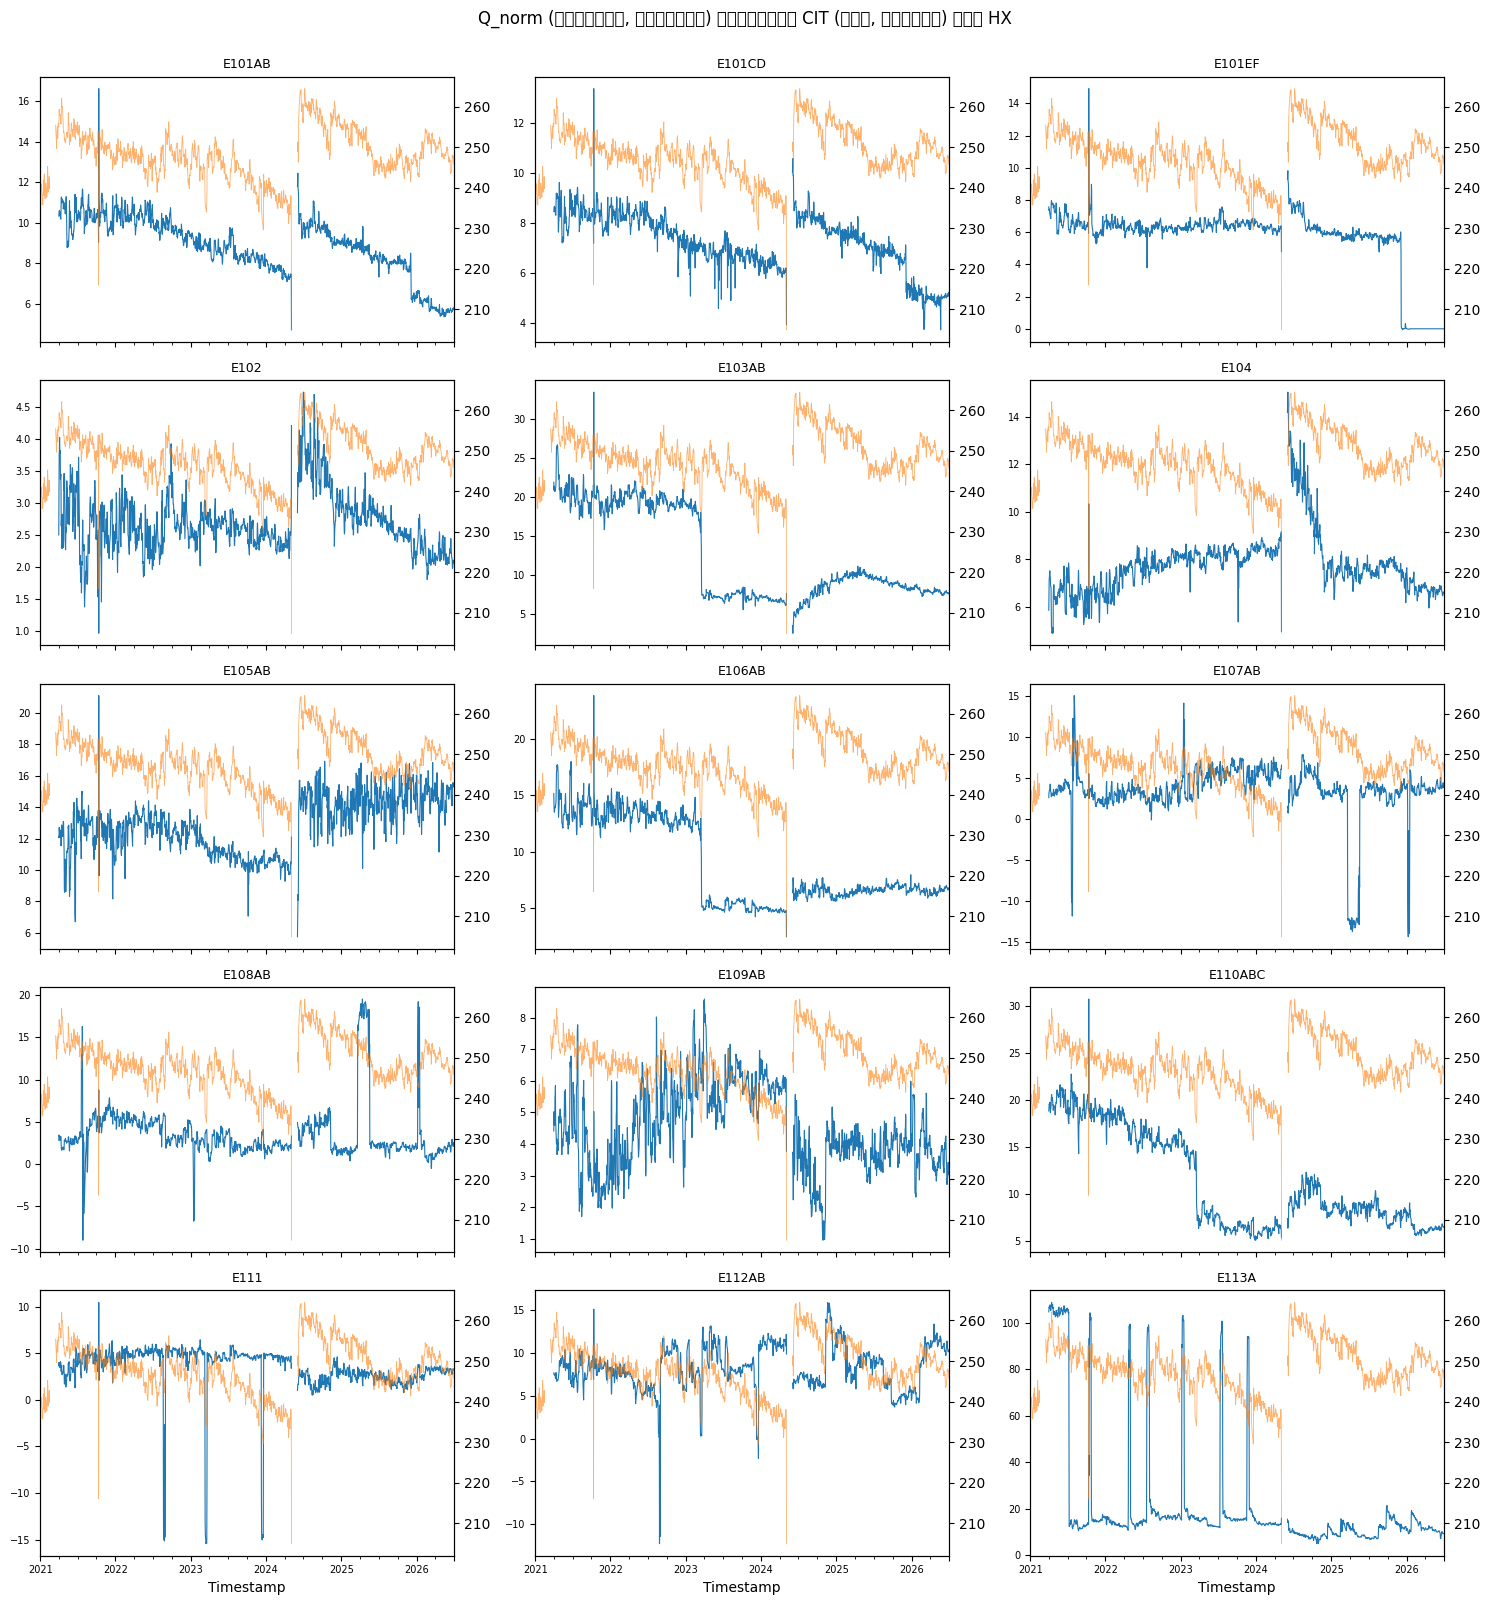

In [13]:
hx_list = list(HX_TAGS.keys())
fig, axes = plt.subplots(5, 3, figsize=(15, 16), sharex=True)
for ax, hx in zip(axes.flat, hx_list):
    q = hx_results[hx]['Q_norm']
    ax2 = ax.twinx()
    q.plot(ax=ax, color='tab:blue', lw=0.8)
    cit.plot(ax=ax2, color='tab:orange', lw=0.6, alpha=0.6)
    ax.set_title(hx, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(hx_list):]:
    ax.axis('off')
fig.suptitle('Q_norm (น้ำเงิน, แกนซ้าย) เทียบกับ CIT (ส้ม, แกนขวา) ต่อ HX', y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_q_vs_cit_grid.png'), dpi=110)
plt.show()

### Fouling rate: ทำ linear fit ของ Q_norm ในแต่ละ "run" (ช่วงต่อเนื่องที่ไม่ใช่ TAM)

วิธีง่ายที่สุด: ตัดข้อมูลเป็นช่วงๆ ตาม TAM window แล้ว fit เส้นตรงใน run ที่มีข้อมูลพอ (≥20 จุด)
slope ที่ได้ (Q_norm ต่อวัน) คือ fouling rate อย่างหยาบ — ถ้าติดลบแปลว่า duty กำลังลดลงตามเวลา (fouling)

In [14]:
def detect_runs(index, tam_mask):
    valid = ~tam_mask.reindex(index).fillna(True)
    runs, start, prev = [], None, None
    for ts, ok in valid.items():
        if ok and start is None:
            start = ts
        if not ok and start is not None:
            runs.append((start, prev))
            start = None
        prev = ts
    if start is not None:
        runs.append((start, prev))
    return runs

fouling_rates = {}
fouling_detail = {}
for hx, df_hx in hx_results.items():
    runs = detect_runs(df_hx.index, TAM_MASK)
    slopes = []
    for (s, e) in runs:
        seg = df_hx.loc[s:e, 'Q_norm'].dropna()
        if len(seg) < 20 or (seg.index[-1] - seg.index[0]).days < 20:
            continue
        x = (seg.index - seg.index[0]).days.values.astype(float)
        slope = np.polyfit(x, seg.values, 1)[0]
        slopes.append(slope)
    fouling_detail[hx] = slopes
    fouling_rates[hx] = np.nanmedian(slopes) if slopes else np.nan

fr_series = pd.Series(fouling_rates).sort_values()
fr_series

E113A     -0.015469
E110ABC   -0.010481
E103AB    -0.007587
E101EF    -0.005612
E106AB    -0.005286
E101AB    -0.004750
E101CD    -0.003921
E108AB    -0.003427
E104      -0.001960
E102      -0.001237
E105AB    -0.000468
E111       0.000348
E107AB     0.001340
E112AB     0.001501
E109AB     0.001613
dtype: float64

**⚠️ ข้อควรระวัง (INFERRED, ไม่ใช่ตัวเลขที่ใช้งานจริงของ pipeline):** slope ด้านบนได้จาก `np.polyfit`
(OLS ธรรมดา) บน `Q_norm` ดิบทั้ง run โดยไม่ได้กรอง in-service state และไม่ได้ใช้ robust estimator —
เป็นวิธีง่ายสุดสำหรับหัดทำความเข้าใจเท่านั้น pipeline การผลิตจริง (`pipeline/compute_fouling_rate.py`)
เจอว่าวิธีนี้ไม่น่าเชื่อถือพอ จึงเปลี่ยนไปใช้ **Theil-Sen slope + in-service mask + reliability gate**
แทน (ผ่านเกณฑ์แค่ 69/125 HX-run) ตัวเลขในตาราง `fr_series` ด้านบนจึงอาจไม่ตรงกับ `Data/Fouling_Rate_By_Run.csv`
ที่เป็นตัวจริง — ใช้ตารางนี้เพื่อดู "ทิศทาง" คร่าวๆ เท่านั้น ไม่ใช่ตัวเลขอ้างอิง

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3026404057.py:11: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(seg.index, intercept + slope * x, color='red', lw=1.5,
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3026404057.py:15: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3026404057.py:15: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3026404057.py:15: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3026404057.py:15: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\302640405

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3026404057.py:16: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_fouling_rate_fit_example.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3026404057.py:16: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_fouling_rate_fit_example.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3026404057.py:16: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_fouling_rate_fit_example.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3026404057.py:16: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_fouling_rate_fit_example.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\302640405

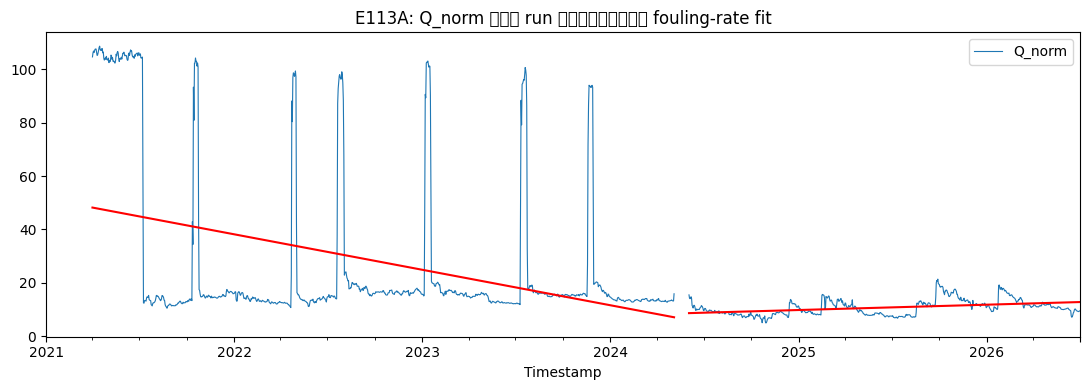

In [15]:
demo_hx = 'E113A'
seg_runs = detect_runs(hx_results[demo_hx].index, TAM_MASK)
fig, ax = plt.subplots()
hx_results[demo_hx]['Q_norm'].plot(ax=ax, lw=0.8, label='Q_norm')
for i, (s, e) in enumerate(seg_runs):
    seg = hx_results[demo_hx].loc[s:e, 'Q_norm'].dropna()
    if len(seg) < 20:
        continue
    x = (seg.index - seg.index[0]).days.values.astype(float)
    slope, intercept = np.polyfit(x, seg.values, 1)
    ax.plot(seg.index, intercept + slope * x, color='red', lw=1.5,
             label='linear fit ต่อ run' if i == 0 else None)
ax.legend()
ax.set_title(f'{demo_hx}: Q_norm ต่อ run พร้อมเส้น fouling-rate fit')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_fouling_rate_fit_example.png'), dpi=110)
plt.show()

### ตรวจจับ cleaning event (การกระโดดขึ้นของ Q_norm) แล้วดูว่า Q/CIT เพิ่มขึ้นแค่ไหนหลัง cleaning

วิธี: หา rolling median ของ Q_norm แล้วดู diff ในช่วง 5 วัน ถ้ากระโดดขึ้นเกิน threshold (สัดส่วนของค่ามัธยฐาน)
ถือว่าเป็น event — เทียบ median ของ Q และ CIT ในหน้าต่าง ±10 วัน (เว้นช่วง gap 2 วัน) ก่อน/หลัง event

In [16]:
def detect_events(q_norm, smooth_win=5, jump_frac=0.15):
    smooth = q_norm.rolling(smooth_win, min_periods=2).median()
    jump = smooth.diff(smooth_win)
    thresh = jump_frac * q_norm.median()
    is_event = jump > thresh
    event_dates, last = [], None
    for d in is_event[is_event].index:
        if last is None or (d - last).days > 10:
            event_dates.append(d)
        last = d
    return event_dates, thresh

PRE, POST, GAP = 10, 10, 2
event_tables = {}
for hx, df_hx in hx_results.items():
    events, thresh = detect_events(df_hx['Q_norm'])
    rows = []
    for ev in events:
        q = df_hx['Q_norm']
        before = q.loc[ev - pd.Timedelta(days=PRE + GAP): ev - pd.Timedelta(days=GAP)].median()
        after = q.loc[ev + pd.Timedelta(days=GAP): ev + pd.Timedelta(days=GAP + POST)].median()
        cb = cit.loc[ev - pd.Timedelta(days=PRE + GAP): ev - pd.Timedelta(days=GAP)].median()
        ca = cit.loc[ev + pd.Timedelta(days=GAP): ev + pd.Timedelta(days=GAP + POST)].median()
        rows.append({'date': ev, 'Q_before': before, 'Q_after': after,
                      'Q_gain_pct': 100 * (after - before) / before if before else np.nan,
                      'CIT_before': cb, 'CIT_after': ca, 'CIT_gain_C': ca - cb})
    event_tables[hx] = pd.DataFrame(rows)

event_tables['E105AB']

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarnin

,date,Q_before,Q_after,Q_gain_pct,CIT_before,CIT_after,CIT_gain_C
0,2021-05-12,9.477838,11.771665,24.202005,252.088520,253.713989,1.625468
1,2021-05-31,10.139884,12.060989,18.946032,252.463768,254.192764,1.728996
2,2021-06-25,11.334288,13.774693,21.531172,255.184051,254.549758,-0.634293
3,2021-07-23,13.150352,12.918716,-1.761447,250.749398,251.745461,0.996063
4,2021-12-24,12.416204,10.605631,-14.582337,247.741176,246.900957,-0.840219
5,2022-02-23,12.051203,12.840854,6.552469,248.185805,249.705021,1.519216
6,2022-08-11,12.735660,13.245700,4.004818,244.315138,248.145344,3.830206
7,2024-06-08,7.712466,14.601957,89.329301,249.405018,263.102770,13.697752
8,2024-08-10,15.065329,13.505775,-10.351943,259.307902,260.826808,1.518906
9,2024-09-15,13.582999,14.883082,9.571403,257.803880,258.515467,0.711586


**⚠️ ข้อควรระวัง (INFERRED, ยังไม่ยืนยัน — ไม่ใช่ cleaning event ที่คอนเฟิร์มแล้ว):** `detect_events`
ด้านบนจับ "การกระโดดขึ้นของ Q_norm เกิน 15% ของค่ามัธยฐาน" เฉยๆ ไม่มีการ cross-check กับ config
การสลับ shell หรือบันทึกการล้างจริง ดังนั้นอาจปนกับเหตุการณ์อื่นที่ไม่ใช่การล้าง (เช่น crude เปลี่ยนสภาพ,
เซนเซอร์กลับมาทำงานปกติ) pipeline การผลิตจริง (`pipeline/export_cleaning_history.py`) เชื่อ event
เฉพาะที่มี config ยืนยันการสลับ shell ประกอบเท่านั้น และ `notebooks/production/06_cleaning_event_validation.ipynb`
มีอยู่เพราะ event ที่ตรวจจับแบบดิบต้องให้วิศวกรยืนยันก่อนเชื่อได้ — ตัวเลข `gain_summary` ด้านล่างจึงเป็นแค่
"ผู้สมัคร" (candidate) ที่ยังไม่ยืนยัน ไม่ใช่ผลการล้างที่คอนเฟิร์มแล้ว

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2625498522.py:12: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2625498522.py:12: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2625498522.py:12: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2625498522.py:12: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2625498522.py:13: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '03_before_after_cleaning_gain.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\26254

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCa

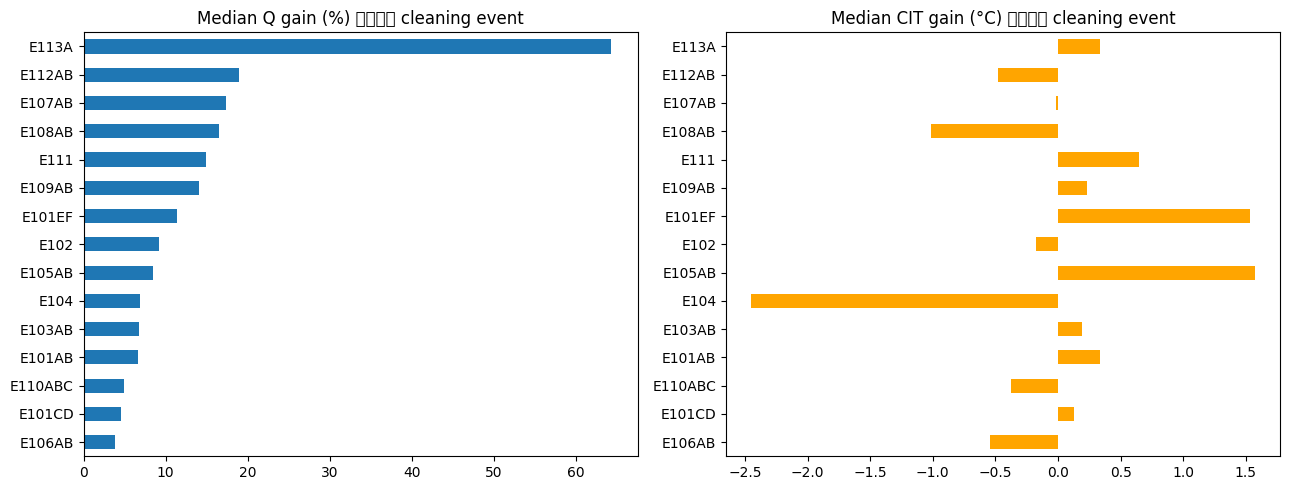

,median_Q_gain_pct,median_CIT_gain_C,n_events
E106AB,3.819176,-0.540914,18.0
E101CD,4.612030,0.126598,2.0
E110ABC,4.941304,-0.378060,20.0
E101AB,6.652193,0.336691,1.0
E103AB,6.718948,0.192438,12.0
E104,6.902694,-2.449855,6.0
E105AB,8.437905,1.572342,18.0
E102,9.186688,-0.171742,28.0
E101EF,11.366827,1.534889,2.0
E109AB,14.056361,0.232541,48.0


In [17]:
gain_summary = pd.DataFrame({
    hx: [df['Q_gain_pct'].median() if len(df) else np.nan,
         df['CIT_gain_C'].median() if len(df) else np.nan,
         len(df)]
    for hx, df in event_tables.items()
}, index=['median_Q_gain_pct', 'median_CIT_gain_C', 'n_events']).T.sort_values('median_Q_gain_pct')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
gain_summary['median_Q_gain_pct'].plot(kind='barh', ax=axes[0], title='Median Q gain (%) หลัง cleaning event')
gain_summary['median_CIT_gain_C'].plot(kind='barh', ax=axes[1], color='orange',
                                        title='Median CIT gain (°C) หลัง cleaning event')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_before_after_cleaning_gain.png'), dpi=110)
plt.show()
gain_summary

## Section 4 — จัดอันดับ HX

จัดอันดับด้วย 2 เกณฑ์แยกกันชัดๆ (ไม่รวมเป็นสูตร black-box ซับซ้อน เพื่อให้ตีความง่าย):
1. **ความสัมพันธ์ Q กับ CIT** (Pearson correlation) — HX ไหนมีผลต่อ CIT มากที่สุด
2. **ขนาด fouling rate** (จาก Section 3) — HX ไหนเสื่อมเร็วที่สุด

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1243883873.py:10: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1243883873.py:10: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1243883873.py:10: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1243883873.py:11: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '04_qcit_correlation_ranking.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1243883873.py:11: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '04_qcit_correlation_ranking.png'), dpi=110)
C:\Use

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


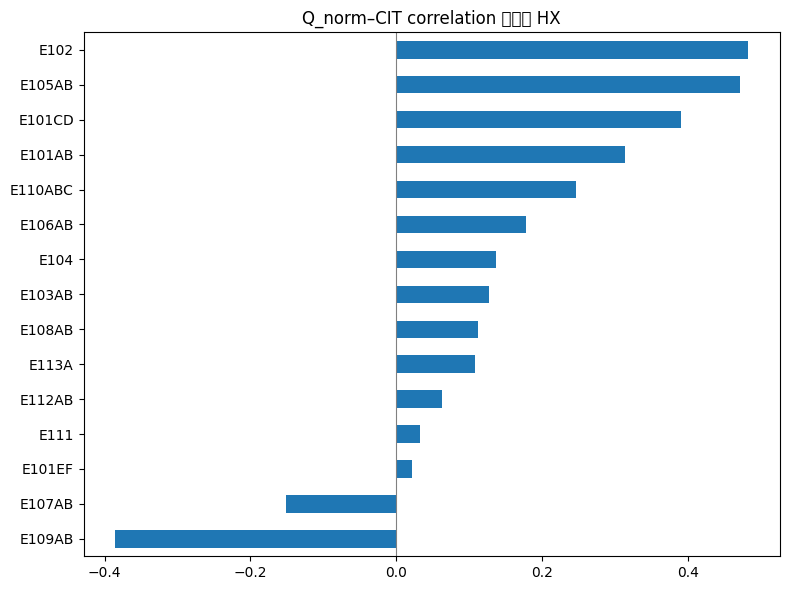

In [18]:
corrs = {}
for hx, df_hx in hx_results.items():
    both = pd.concat([df_hx['Q_norm'], cit], axis=1).dropna()
    corrs[hx] = both.corr().iloc[0, 1] if len(both) > 30 else np.nan
corr_series = pd.Series(corrs).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
corr_series.plot(kind='barh', ax=ax, title='Q_norm–CIT correlation ต่อ HX')
ax.axvline(0, color='grey', lw=0.8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_qcit_correlation_ranking.png'), dpi=110)
plt.show()

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4288541596.py:4: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4288541596.py:4: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4288541596.py:4: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4288541596.py:4: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4288541596.py:4: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\4288541596.py:4: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missin

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCac

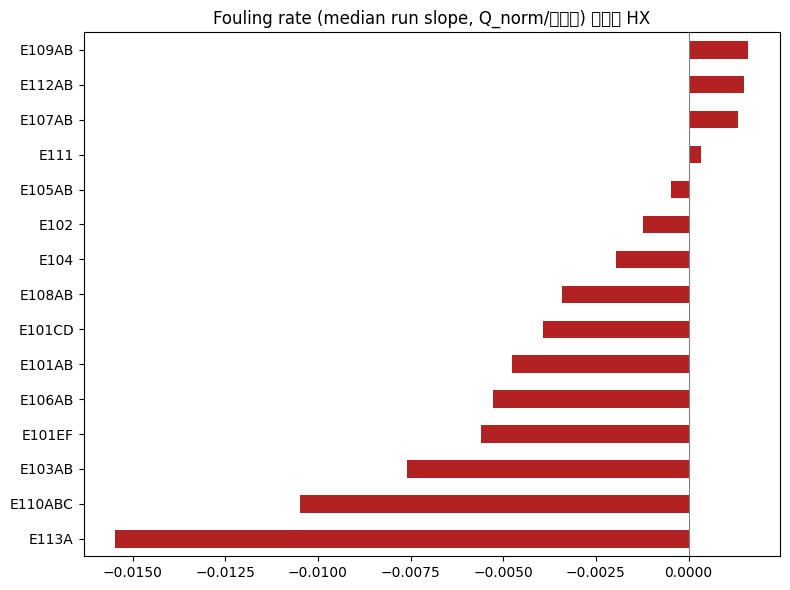

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
fr_series.plot(kind='barh', ax=ax, color='firebrick', title='Fouling rate (median run slope, Q_norm/วัน) ต่อ HX')
ax.axvline(0, color='grey', lw=0.8)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_fouling_rate_ranking.png'), dpi=110)
plt.show()

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:11: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:11: UserWarning: Glyph 3641 (\N{THAI CHARACTER SARA UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:11: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:11: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:11: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:11: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) 

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:12: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '04_combined_risk_scatter.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:12: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '04_combined_risk_scatter.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:12: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '04_combined_risk_scatter.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:12: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '04_combined_risk_scatter.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3264227888.py:12: Use

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\loc

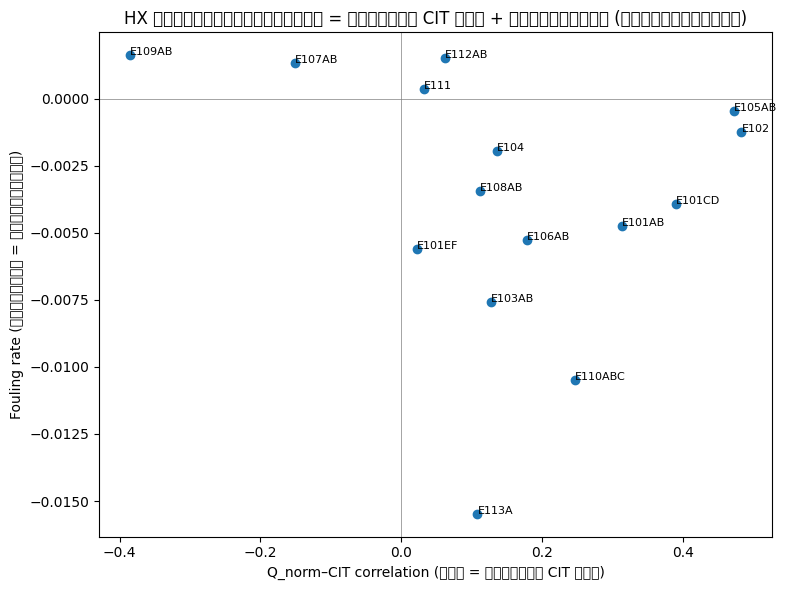

In [20]:
rank_df = pd.DataFrame({'qcit_corr': corr_series, 'fouling_rate': fr_series}).dropna()
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(rank_df['qcit_corr'], rank_df['fouling_rate'])
for hx, row in rank_df.iterrows():
    ax.annotate(hx, (row['qcit_corr'], row['fouling_rate']), fontsize=8)
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)
ax.set_xlabel('Q_norm–CIT correlation (สูง = มีผลต่อ CIT มาก)')
ax.set_ylabel('Fouling rate (ติดลบมาก = เสื่อมเร็ว)')
ax.set_title('HX ที่อยู่มุมล่างขวา = มีผลต่อ CIT มาก + เสื่อมเร็ว (ควรจับตาก่อน)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_combined_risk_scatter.png'), dpi=110)
plt.show()

### รวม 2 เกณฑ์เป็นตารางเดียว (quick view เท่านั้น — ไม่ใช่ risk score ที่ใช้งานจริง)

Rank-normalize ทั้งสองแกน (0 = แย่สุด, 1 = ดีสุด) แล้วรวมง่ายๆ เพื่อดูภาพรวมเร็วๆ ว่า HX ไหน
"มีผลต่อ CIT มาก + เสื่อมเร็ว" พร้อมกัน — pipeline การผลิตจริงมี risk score ที่ละเอียดกว่านี้มาก
(`Engineering_Priority_Score.csv` จาก `08_cleaning_priority.ipynb`, รวม safety weight, effort tier,
trajectory ด้วย) ตารางนี้เป็นแค่มุมมองเร็วๆ ของตัวเอง ไม่ควรใช้แทนอันนั้น

In [21]:
rank_df['impact_rank'] = rank_df['qcit_corr'].abs().rank(pct=True)
rank_df['fouling_severity_rank'] = (-rank_df['fouling_rate']).rank(pct=True)  # ยิ่งลบมาก (เสื่อมเร็ว) ยิ่งได้ rank สูง
rank_df['combined_quick_score'] = (rank_df['impact_rank'] + rank_df['fouling_severity_rank']) / 2
rank_df.sort_values('combined_quick_score', ascending=False)[
    ['qcit_corr', 'fouling_rate', 'impact_rank', 'fouling_severity_rank', 'combined_quick_score']]

,qcit_corr,fouling_rate,impact_rank,fouling_severity_rank,combined_quick_score
E110ABC,0.247054,-0.010481,0.666667,0.933333,0.800000
E101CD,0.390345,-0.003921,0.866667,0.600000,0.733333
E101AB,0.313572,-0.004750,0.733333,0.666667,0.700000
E102,0.483210,-0.001237,1.000000,0.400000,0.700000
E106AB,0.178077,-0.005286,0.600000,0.733333,0.666667
E105AB,0.472250,-0.000468,0.933333,0.333333,0.633333
E103AB,0.127494,-0.007587,0.400000,0.866667,0.633333
E113A,0.108181,-0.015469,0.266667,1.000000,0.633333
E104,0.136385,-0.001960,0.466667,0.466667,0.466667
E101EF,0.021938,-0.005612,0.066667,0.800000,0.433333


## Section 5 — Feature Engineering สำหรับพยากรณ์ CIT

สร้างตารางฟีเจอร์จาก: Q_norm/ΔT ต่อ HX, คุณสมบัติ crude (forward-fill เท่านั้น ไม่ leak อนาคต),
ฤดูกาล (month sin/cos), และค่า CIT ในอดีต (lag1, lag7, rolling7) — ใช้ตรวจสอบว่าฟีเจอร์ไหนมีความสัมพันธ์กับ CIT มากที่สุด

In [22]:
feat = pd.DataFrame(index=proc_clean.index)
for hx, df_hx in hx_results.items():
    feat[f'{hx}_Q_norm'] = df_hx['Q_norm']
    feat[f'{hx}_dT'] = df_hx['dT']
for col in crude_raw.columns:
    safe = col.split(' (')[0].replace(' ', '_')
    feat[f'crude_{safe}'] = crude_raw[col].reindex(
        feat.index.union(crude_raw.index)).sort_index().ffill().reindex(feat.index)
feat['month_sin'] = np.sin(2 * np.pi * feat.index.month / 12)
feat['month_cos'] = np.cos(2 * np.pi * feat.index.month / 12)
feat['CIT'] = cit
feat['CIT_lag1'] = cit.shift(1)
feat['CIT_lag7'] = cit.shift(7)
feat['CIT_roll7'] = cit.rolling(7).mean().shift(1)
feat = feat[~TAM_MASK.reindex(feat.index, fill_value=False)]
feat_clean = feat.dropna()

print('feature table:', feat_clean.shape)
feature_cols = [c for c in feat_clean.columns if c != 'CIT']
corr_vs_cit = feat_clean[feature_cols + ['CIT']].corr()['CIT'].drop('CIT').sort_values()
corr_vs_cit

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3143758307.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feat.index.union(crude_raw.index)).sort_index().ffill().reindex(feat.index)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3143758307.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  feat.index.union(crude_raw.index)).sort_index().ffill().reindex(feat.index)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3143758307.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future

feature table: (1883, 41)


E109AB_Q_norm                     -0.386313
E109AB_dT                         -0.295343
E107AB_Q_norm                     -0.150726
E107AB_dT                         -0.115744
month_cos                         -0.109500
month_sin                         -0.098671
crude_Specific_gravity_at_15.6C   -0.037841
E104_dT                            0.004262
E101EF_Q_norm                      0.020383
E111_Q_norm                        0.033096
E111_dT                            0.056022
E112AB_Q_norm                      0.063121
crude_Carbon_Residue               0.093761
E112AB_dT                          0.100981
crude_Asphaltenes                  0.107586
E113A_Q_norm                       0.108675
E103AB_dT                          0.108985
E113A_dT                           0.109172
E108AB_Q_norm                      0.111943
crude_API                          0.120433
E103AB_Q_norm                      0.129800
E108AB_dT                          0.130302
E104_Q_norm                     

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3557301129.py:4: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3557301129.py:4: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3557301129.py:4: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3557301129.py:4: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3557301129.py:4: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\3557301129.py:4: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing 

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\l

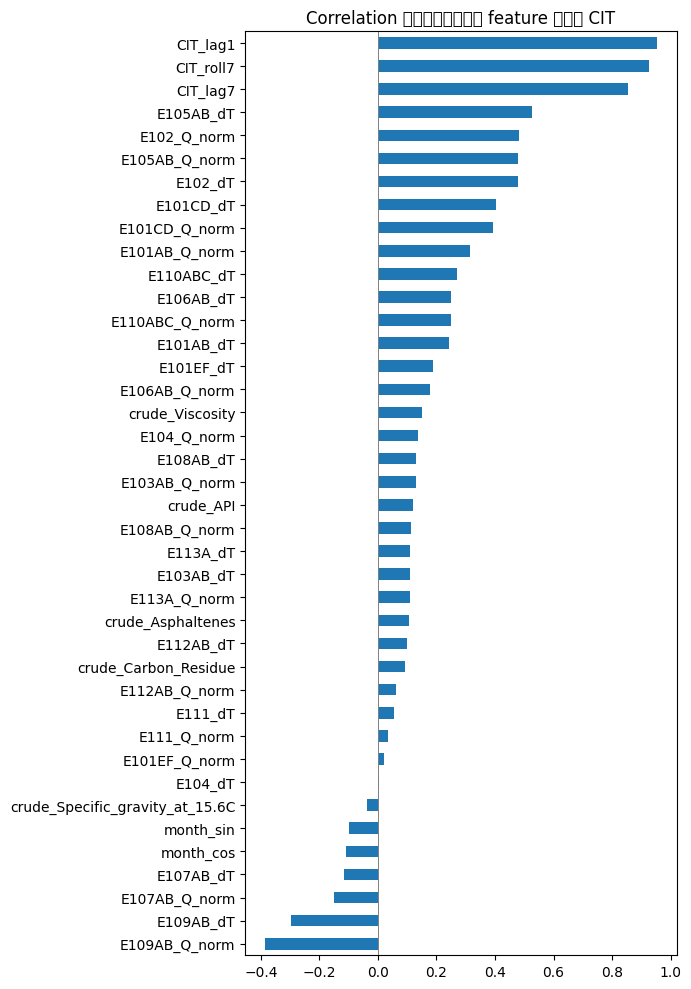

In [23]:
fig, ax = plt.subplots(figsize=(7, 10))
corr_vs_cit.plot(kind='barh', ax=ax, title='Correlation ของแต่ละ feature กับ CIT')
ax.axvline(0, color='grey', lw=0.7)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_feature_correlation_ranking.png'), dpi=110)
plt.show()

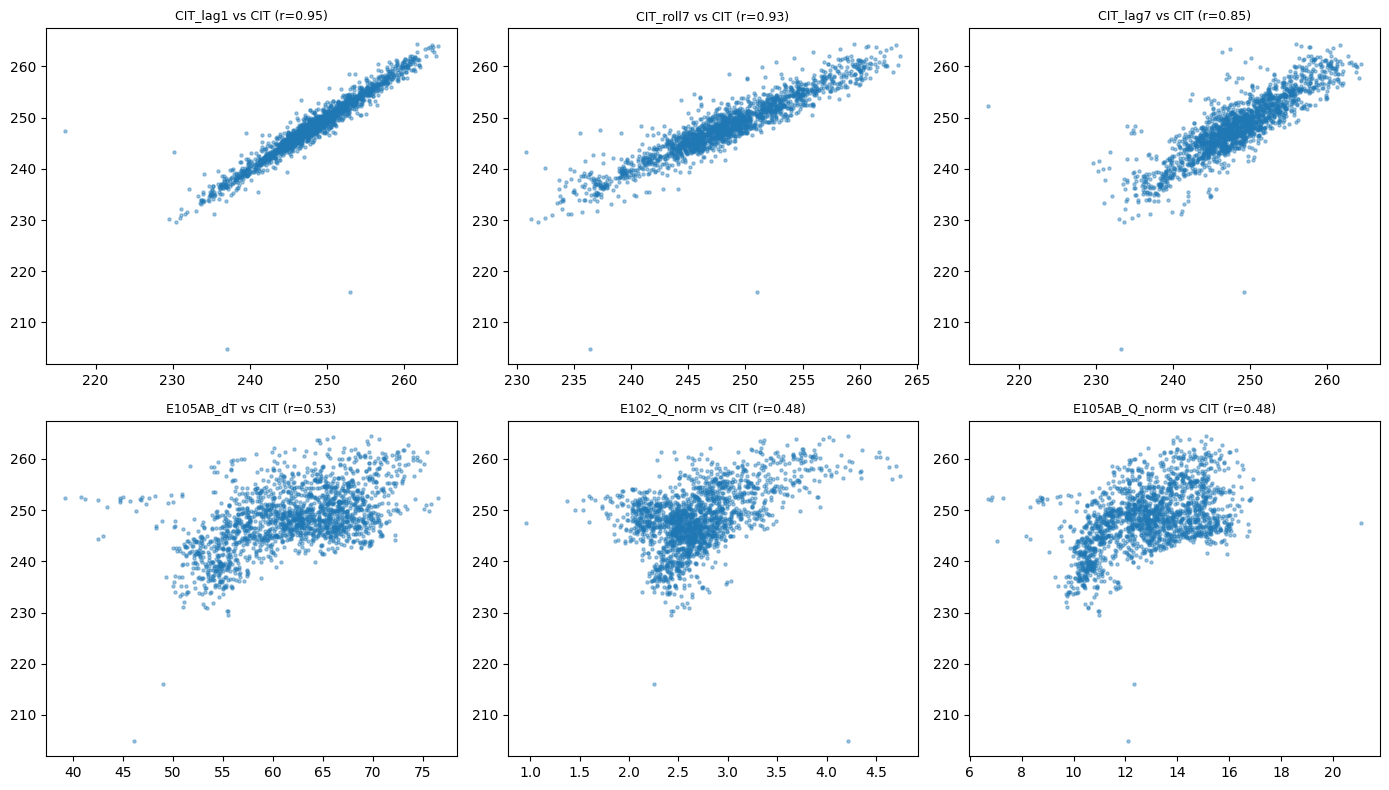

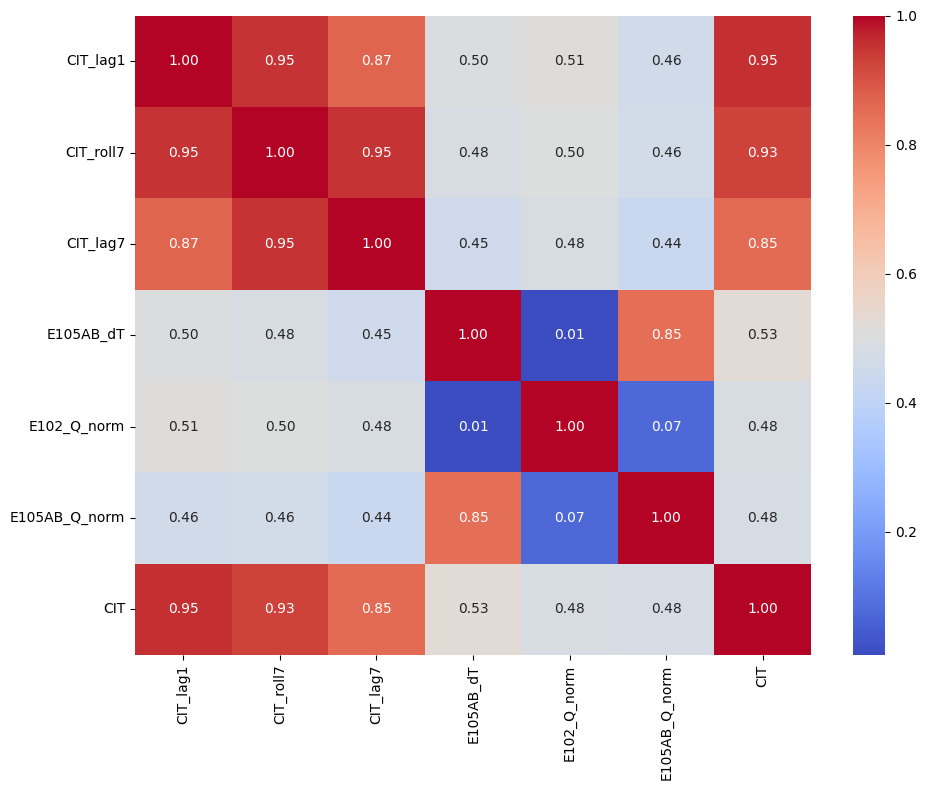

In [24]:
top_feats = corr_vs_cit.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, f in zip(axes.flat, top_feats):
    ax.scatter(feat_clean[f], feat_clean['CIT'], s=5, alpha=0.4)
    ax.set_title(f'{f} vs CIT (r={corr_vs_cit[f]:.2f})', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_top_feature_scatter.png'), dpi=110)
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(feat_clean[top_feats + ['CIT']].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_correlation_heatmap.png'), dpi=110)
plt.show()

## Section 6 — เปรียบเทียบโมเดล + สำรวจแนวคิด Network

### 6.1 เทรนโมเดลพยากรณ์ CIT — เทียบกับ baseline "วันนี้ = เมื่อวาน"

**สำคัญ:** แบ่ง train/test แบบ **เรียงตามเวลา** (train = ช่วงต้น, test = ช่วงหลัง) ไม่สุ่มแบ่ง
เพราะข้อมูล time-series ถ้าสุ่มแบ่งจะมีการ "แอบดูอนาคต" (leakage) — และต้องเทียบกับ baseline ง่ายๆ เสมอ
ถึงจะรู้ว่าโมเดลที่ซับซ้อนกว่าคุ้มค่าจริงหรือแค่ดูดีเฉยๆ

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

X = feat_clean[feature_cols]
y = feat_clean['CIT']
split = int(len(feat_clean) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, random_state=0).fit(X_train, y_train)

preds = {
    'Persistence (เมื่อวาน)': X_test['CIT_lag1'],
    'Linear Regression': lr.predict(X_test),
    'Random Forest': rf.predict(X_test),
}
metrics = pd.DataFrame({
    name: [r2_score(y_test, p), np.sqrt(mean_squared_error(y_test, p))]
    for name, p in preds.items()
}, index=['R2', 'RMSE']).T.sort_values('R2', ascending=False)
metrics

,R2,RMSE
Persistence (เมื่อวาน),0.883561,0.963005
Random Forest,0.516221,1.962924
Linear Regression,-0.209349,3.103528


C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1668238123.py:5: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1668238123.py:5: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1668238123.py:5: UserWarning: Glyph 3639 (\N{THAI CHARACTER SARA UEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1668238123.py:5: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1668238123.py:5: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\1668238123.py:5: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing fr

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCach

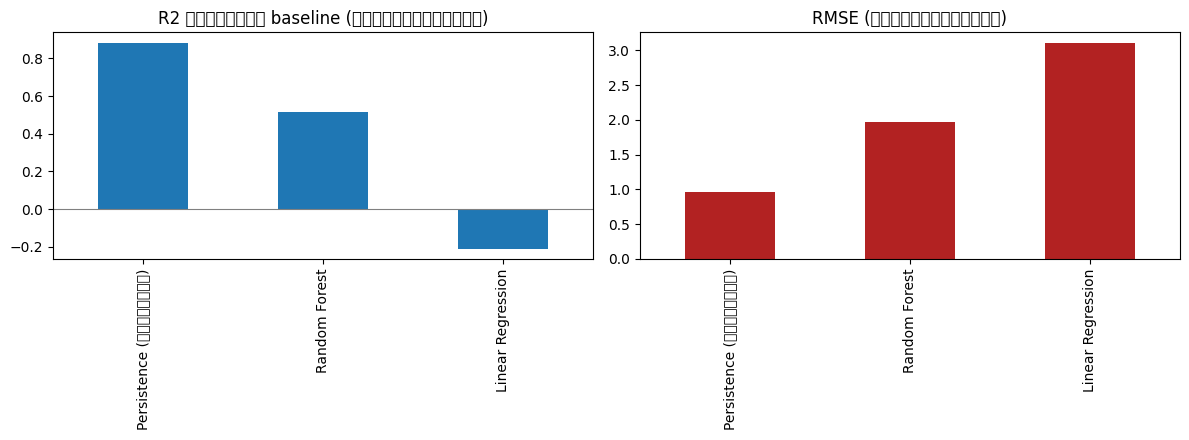

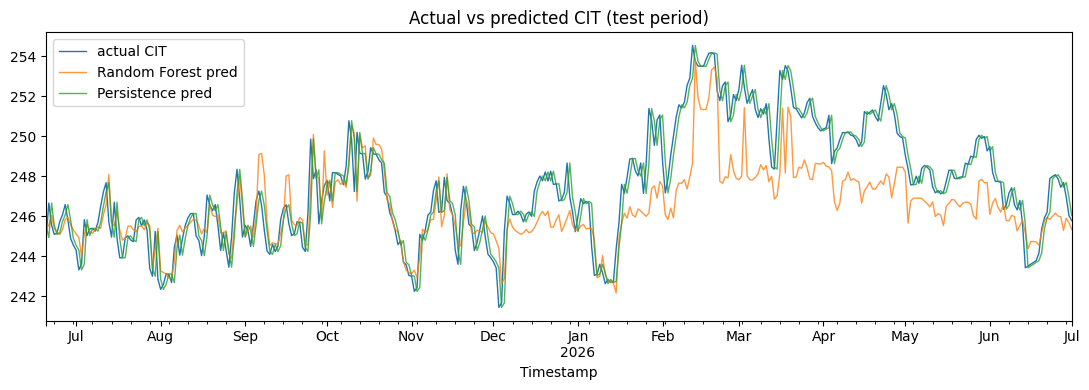

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
metrics['R2'].plot(kind='bar', ax=axes[0], title='R2 เทียบกับ baseline (ยิ่งสูงยิ่งดี)')
axes[0].axhline(0, color='grey', lw=0.8)
metrics['RMSE'].plot(kind='bar', ax=axes[1], color='firebrick', title='RMSE (ยิ่งต่ำยิ่งดี)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_model_comparison.png'), dpi=110)
plt.show()

fig, ax = plt.subplots()
y_test.plot(ax=ax, label='actual CIT', lw=1)
pd.Series(preds['Random Forest'], index=y_test.index).plot(ax=ax, label='Random Forest pred', lw=1, alpha=0.8)
pd.Series(preds['Persistence (เมื่อวาน)'], index=y_test.index).plot(ax=ax, label='Persistence pred', lw=1, alpha=0.8)
ax.legend()
ax.set_title('Actual vs predicted CIT (test period)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_actual_vs_predicted.png'), dpi=110)
plt.show()

**สังเกต:** ถ้า Persistence (แค่ทายว่า "พรุ่งนี้ = วันนี้") ได้ R2/RMSE ใกล้เคียงหรือดีกว่าโมเดล ML —
แปลว่า CIT มีลักษณะ autocorrelated สูงมาก (ค่าเปลี่ยนช้า) และโมเดลที่ซับซ้อนกว่ายังไม่ได้ช่วยอะไรเพิ่มจริงๆ
ควรตีความ feature importance ด้านล่างเป็น "ความสัมพันธ์เชิงสถิติ" ไม่ใช่ความเป็นเหตุ-ผลเชิงฟิสิกส์

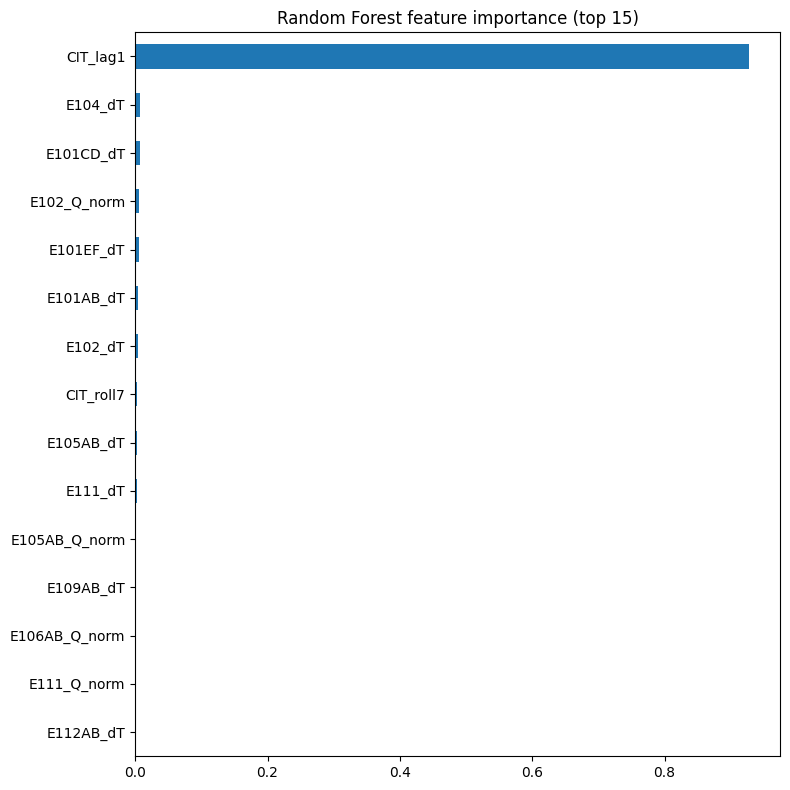

In [27]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
importances.head(15).plot(kind='barh', ax=ax, title='Random Forest feature importance (top 15)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_feature_importance.png'), dpi=110)
plt.show()

### 6.2 แนวคิด Network — HX เชื่อมกันเป็นสายการไหลของ crude

ตามลำดับการไหลจริงของ crude (ความรู้หน้างาน ไม่ใช่โมเดลที่ fit จากข้อมูล):
CPHT-1 (ก่อนเข้า desalter): `E101AB/CD/EF -> E102`
CPHT-2 (ก่อนเข้าเตา): `E103AB -> E104 -> E105AB` และอีกสาย `E106AB -> E107AB -> E108AB -> E109AB` และ `E110ABC -> E111 -> E112AB -> E113A (CIT)`

**ข้อควรระวังที่ต้องพูดตรงๆ:** นี่เป็นแค่ลำดับตำแหน่งทางกายภาพ (topology) ไม่ใช่โมเดลจำลองการไหลความร้อนจริง (thermal cascade)
เพราะไม่มีข้อมูล Area/LMTD ของแต่ละ HX ที่ยืนยันแล้วในชุดข้อมูลนี้ การจะสร้างโมเดล cascade ที่แม่นยำ
ต้องมีข้อมูล mechanical datasheet เพิ่มเติมและการ validate กับพนักงานหน้างาน — ยังทำไม่ได้ในระดับนี้
สิ่งที่ทำได้แบบซื่อสัตย์คือทดลองเชิงข้อมูล (data-driven) ว่า "การรู้ค่า Q ของ HX ตัวก่อนหน้า ช่วยพยากรณ์อะไรต่อได้ไหม"

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\848531840.py:29: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\848531840.py:29: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\848531840.py:29: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\848531840.py:29: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\848531840.py:29: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\848531840.py:29: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}

C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\l

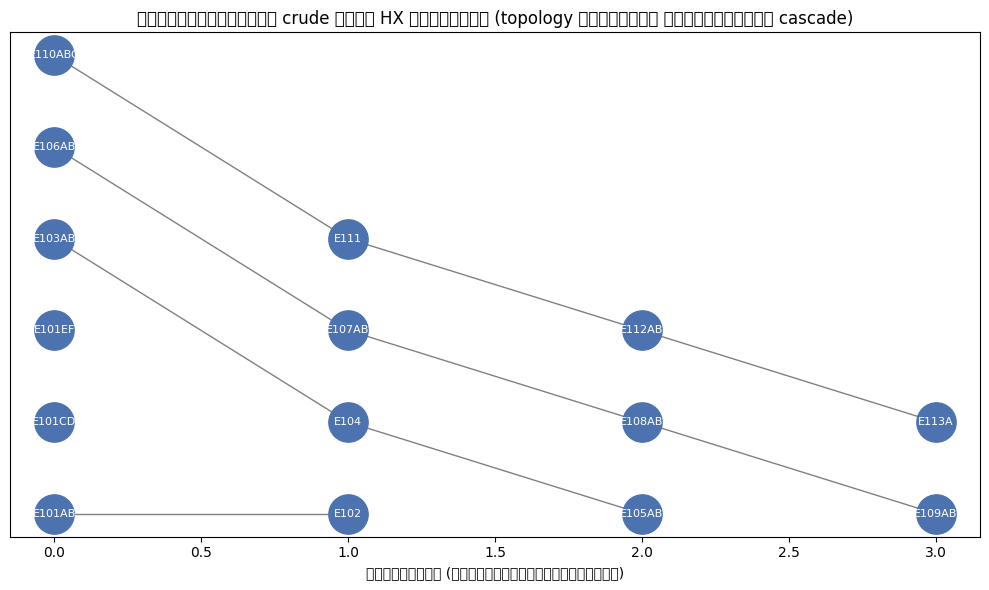

In [28]:
chain = {
    'E101AB': None, 'E101CD': None, 'E101EF': None, 'E102': 'E101AB',
    'E103AB': None, 'E104': 'E103AB', 'E105AB': 'E104',
    'E106AB': None, 'E107AB': 'E106AB', 'E108AB': 'E107AB', 'E109AB': 'E108AB',
    'E110ABC': None, 'E111': 'E110ABC', 'E112AB': 'E111', 'E113A': 'E112AB',
}
fig, ax = plt.subplots(figsize=(10, 6))
levels = {}
def depth(hx):
    if hx not in levels:
        levels[hx] = 0 if chain[hx] is None else depth(chain[hx]) + 1
    return levels[hx]
for hx in chain:
    depth(hx)
lanes = {}
for hx, d in levels.items():
    lanes.setdefault(d, []).append(hx)
for d, hxs in lanes.items():
    for i, hx in enumerate(hxs):
        ax.scatter(d, i, s=800, color='#4c72b0')
        ax.annotate(hx, (d, i), ha='center', va='center', color='white', fontsize=8)
        if chain[hx] is not None:
            pd_ = levels[chain[hx]]
            pi = lanes[pd_].index(chain[hx])
            ax.plot([pd_, d], [pi, i], color='grey', lw=1, zorder=0)
ax.set_xlabel('ลำดับขั้น (ใกล้เตามากขึ้นทางขวา)')
ax.set_yticks([])
ax.set_title('ลำดับการไหลของ crude ผ่าน HX แต่ละตัว (topology เท่านั้น ไม่ใช่โมเดล cascade)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_network_topology.png'), dpi=110)
plt.show()

### การทดลอง: เพิ่ม feature ของ HX ต้นน้ำ (upstream) ช่วยพยากรณ์ CIT ของ HX ปลายน้ำได้ไหม?

ทดลองแบบเจาะจง: ใช้ `E112AB` เป็น target ทดสอบ (HX ก่อน E113A ตัวสุดท้าย) เทียบโมเดลที่มี vs ไม่มี
feature ของ `E111` (upstream) แบบ lag-1 วัน — เพื่อดูว่า "รู้ค่า upstream ล่วงหน้า" ช่วยพยากรณ์ Q_norm
ของ HX ถัดไปได้จริงหรือไม่ (การทดลองนี้เป็นแค่ตัวอย่างสำรวจ ไม่ใช่ผลสรุปสุดท้าย)

In [29]:
target_hx, upstream_hx = 'E112AB', 'E111'
local = pd.DataFrame(index=proc_clean.index)
local['y'] = hx_results[target_hx]['Q_norm']
for lag in [1, 2, 3]:
    local[f'y_lag{lag}'] = local['y'].shift(lag)
local_with_upstream = local.copy()
local_with_upstream['upstream_Q_norm_lag1'] = hx_results[upstream_hx]['Q_norm'].shift(1)

for label, table in [('ไม่มี upstream', local), ('มี upstream', local_with_upstream)]:
    d = table.dropna()
    split_i = int(len(d) * 0.8)
    cols = [c for c in d.columns if c != 'y']
    Xtr, Xte = d[cols].iloc[:split_i], d[cols].iloc[split_i:]
    ytr, yte = d['y'].iloc[:split_i], d['y'].iloc[split_i:]
    model = LinearRegression().fit(Xtr, ytr)
    r2 = r2_score(yte, model.predict(Xte))
    print(f'{label}: R2 = {r2:.4f}  (n_features={len(cols)}, n_test={len(yte)})')

ไม่มี upstream: R2 = 0.9747  (n_features=3, n_test=377)
มี upstream: R2 = 0.9728  (n_features=4, n_test=377)


**⚠️ ผลข้างบน (E112AB←E111 เท่านั้น) ยังตอบคำถาม cascade ไม่ได้จริง:** R² แทบไม่ต่างกัน
(0.9747 vs 0.9728) เพราะ `y_lag1/2/3` (autoregressive ของตัวเองวันก่อนหน้า) น่าจะอธิบาย variance
เกือบทั้งหมดไปแล้ว ทำให้แยกไม่ออกว่า "upstream ไม่มีผลจริง" หรือ "lag-1 ของตัวเองกลบสัญญาณ upstream ไปหมด"
และเป็นการทดสอบแค่คู่เดียวจาก chain 15 ตัว ไม่ใช่คำตอบของคำถามที่ตั้งไว้ตอนต้น ("ถ้า Q ตัวนี้ลด
ตัวไหนจะลดตาม ส่งผลต่อ CIT แบบไหน") — ทำ 2 อย่างเพิ่มเพื่อให้เห็นภาพชัดขึ้น:
1. **Lagged cross-correlation** ก่อน ว่า upstream นำ (lead) downstream จริงไหมที่ lag ไหน ก่อนเชื่อผล regression
2. **ทดสอบซ้ำกับ edge อื่นในสาย** ไม่ใช่แค่คู่เดียว

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2455886491.py:15: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2455886491.py:15: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2455886491.py:15: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2455886491.py:15: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2455886491.py:16: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '06_cross_correlation_by_edge.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\24558864

C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2455886491.py:16: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '06_cross_correlation_by_edge.png'), dpi=110)
C:\Users\saard\AppData\Local\Temp\ipykernel_47972\2455886491.py:16: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(FIG_DIR, '06_cross_correlation_by_edge.png'), dpi=110)


C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\saard\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\lo

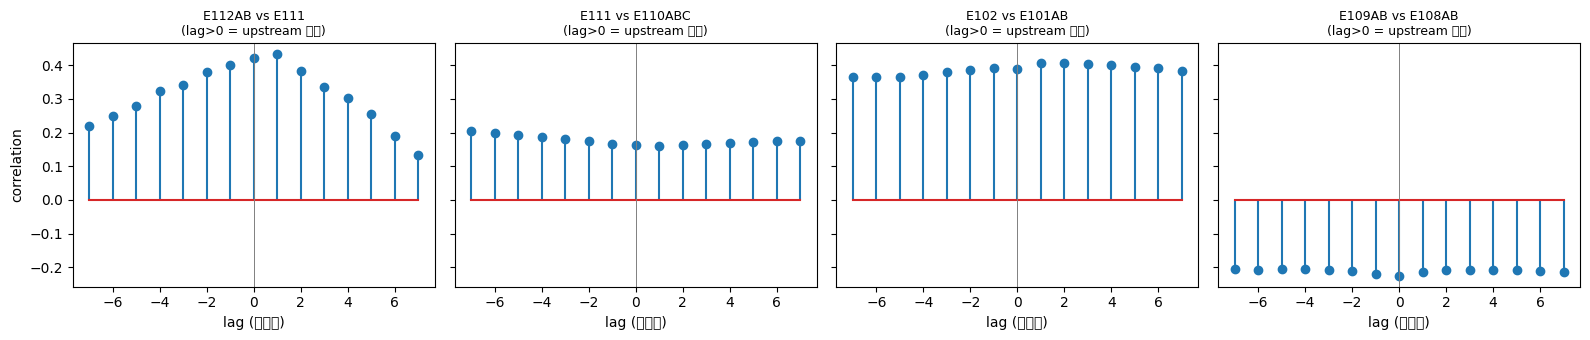

In [30]:
edges_to_test = [('E112AB', 'E111'), ('E111', 'E110ABC'), ('E102', 'E101AB'), ('E109AB', 'E108AB')]

fig, axes = plt.subplots(1, len(edges_to_test), figsize=(4 * len(edges_to_test), 3.5), sharey=True)
for ax, (down, up) in zip(axes, edges_to_test):
    a = hx_results[down]['Q_norm']
    b = hx_results[up]['Q_norm']
    both = pd.concat([a, b], axis=1, keys=['down', 'up']).dropna()
    lags = range(-7, 8)
    xcorr = [both['up'].shift(lag).corr(both['down']) for lag in lags]
    ax.stem(list(lags), xcorr)
    ax.axvline(0, color='grey', lw=0.7)
    ax.set_title(f'{down} vs {up}\n(lag>0 = upstream นำ)', fontsize=9)
    ax.set_xlabel('lag (วัน)')
axes[0].set_ylabel('correlation')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_cross_correlation_by_edge.png'), dpi=110)
plt.show()

In [31]:
edge_results = []
for down, up in edges_to_test:
    local = pd.DataFrame(index=proc_clean.index)
    local['y'] = hx_results[down]['Q_norm']
    for lag in [1, 2, 3]:
        local[f'y_lag{lag}'] = local['y'].shift(lag)
    local_up = local.copy()
    local_up['upstream_Q_norm_lag1'] = hx_results[up]['Q_norm'].shift(1)

    row = {'downstream': down, 'upstream': up}
    for label, table in [('r2_no_upstream', local), ('r2_with_upstream', local_up)]:
        d = table.dropna()
        split_i = int(len(d) * 0.8)
        cols = [c for c in d.columns if c != 'y']
        Xtr, Xte = d[cols].iloc[:split_i], d[cols].iloc[split_i:]
        ytr, yte = d['y'].iloc[:split_i], d['y'].iloc[split_i:]
        model = LinearRegression().fit(Xtr, ytr)
        row[label] = r2_score(yte, model.predict(Xte))
    row['delta_r2'] = row['r2_with_upstream'] - row['r2_no_upstream']
    edge_results.append(row)

edge_df = pd.DataFrame(edge_results).set_index(['downstream', 'upstream'])
edge_df

,,r2_no_upstream,r2_with_upstream,delta_r2
downstream,upstream,,,
E112AB,E111,0.974659,0.972836,-0.001823
E111,E110ABC,0.865257,0.874509,0.009252
E102,E101AB,0.899662,0.914419,0.014757
E109AB,E108AB,0.716586,0.716593,0.000007


## สรุปและขั้นต่อไป

- ทุกสูตรและ threshold ใน notebook นี้เขียนใหม่เอง สามารถปรับ (`SHUTDOWN_THRESH`, `jump_frac`, z-score window ฯลฯ) ได้ตรงๆ ในเซลล์ที่เกี่ยวข้อง
- Section 3-4 ใช้ Q_norm เป็น proxy ของ U จริง — ถ้าต้องการค่า U ที่แม่นยำต้องหาข้อมูล Area/LMTD ของแต่ละ HX มาเพิ่ม
- Fouling rate (Section 3) และ cleaning-event gain (Section 3) เป็น **INFERRED แบบง่าย ยังไม่ยืนยัน** — ดูคำเตือนในเซลล์ที่เกี่ยวข้อง อย่าถือเป็นตัวเลขทางการ
- Finding ที่เจอเอง (persistence baseline แข่งกับ ML ในการพยากรณ์ CIT) ตรงกับสิ่งที่เคยพบใน pipeline เดิม — เป็น sanity check ที่ดีว่าไม่ได้เข้าใจผิดอะไรไป
- **Network section (6.2) เป็นการสำรวจสัญญาณเบื้องต้น (exploratory signal check) เท่านั้น ไม่ใช่โมเดล cascade/what-if ที่ผ่านการยืนยัน** —
  ทดสอบได้แค่ 4 edge จาก chain 15 ตัว, cross-correlation ที่ดูก็ยังไม่ควบคุม confounder ร่วม (เช่น total charge เปลี่ยนพร้อมกันทั้งสาย
  ทำให้ HX ทุกตัวขยับพร้อมกันโดยไม่ต้องมี "cascade" จริง) ถ้าจะทำโมเดล cascade ที่ตอบคำถาม "Q ตัวนี้ลด ตัวไหนลดตาม ส่งผลต่อ CIT แค่ไหน"
  ได้จริง ต้องมี: ทดสอบครบทั้ง 15 node, feature ที่แยก confounder ร่วม (เช่น de-trend ด้วย total charge ก่อน), และคุยกับวิศวกรหน้างาน
  เพื่อยืนยัน topology ที่ใช้จริง — ยังไม่ได้ทำในระดับนี้